In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [5]:
sys.path.append('C:/Users/rishe/Dissertation')

In [6]:
EXP_ID = f'exp_10_reg_via_classification_v1'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [7]:
df_long = pd.read_parquet(DATA_PATH)

In [8]:
df_long.shape

(4741665, 11)

In [9]:
df_long['station_id'].nunique()

293

### Data Pre-processing

In [10]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [11]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [12]:
df_long = df_long.dropna(subset=['rainfall'])

In [13]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [14]:
station_summary.head()

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847


In [15]:
station_summary['rainy_days'].sum()

1121149

In [16]:
summary = (
    df_long
    .groupby('station_id')
    .agg(
        lat_missing=('lat', lambda x: x.isna().any()),
        lon_missing=('lon', lambda x: x.isna().any())
    )
)

summary['missing_type'] = np.select(
    [
        summary['lat_missing'] & summary['lon_missing'],
        summary['lat_missing'],
        summary['lon_missing']
    ],
    [
        'both_missing',
        'lat_missing',
        'lon_missing'
    ],
    default='data_available'
)

summary.value_counts('missing_type')


missing_type
data_available    277
both_missing       16
Name: count, dtype: int64

### Binning

In [17]:
df_long['rainfall'].describe(percentiles = [
0.750, 0.755, 0.760, 0.765, 0.770,
0.775, 0.780, 0.785, 0.790, 0.795,
0.800, 0.805, 0.810, 0.815, 0.820,
0.825, 0.830, 0.835, 0.840, 0.845,
0.850, 0.855, 0.860, 0.865, 0.870,
0.875, 0.880, 0.885, 0.890, 0.895,
0.900, 0.905, 0.910, 0.915, 0.920,
0.925, 0.930, 0.935, 0.940, 0.945,
0.950, 0.955, 0.960, 0.965, 0.970,
0.975, 0.980, 0.985, 0.990,
0.995,
0.9995
]
)

count     3.959148e+06
mean      5.485089e+00
std       1.714293e+01
min       0.000000e+00
50%       0.000000e+00
75%       1.400000e+00
75.5%     1.800000e+00
76%       2.000000e+00
76.5%     2.200000e+00
77%       2.500000e+00
77.5%     2.600000e+00
78%       3.000000e+00
78.5%     3.300000e+00
79%       3.600000e+00
79.5%     4.000000e+00
80%       4.300000e+00
80.5%     4.700000e+00
81%       5.100000e+00
81.5%     5.300000e+00
82%       5.800000e+00
82.5%     6.400000e+00
83%       6.800000e+00
83.5%     7.300000e+00
84%       7.600000e+00
84.5%     8.200000e+00
85%       8.900000e+00
85.5%     9.400000e+00
86%       1.020000e+01
86.5%     1.070000e+01
87%       1.140000e+01
87.5%     1.220000e+01
88%       1.270000e+01
88.5%     1.360000e+01
89%       1.450000e+01
89.5%     1.520000e+01
90%       1.640000e+01
90.5%     1.750000e+01
91%       1.860000e+01
91.5%     2.000000e+01
92%       2.110000e+01
92.5%     2.280000e+01
93%       2.420000e+01
93.5%     2.580000e+01
94%       2

In [18]:
df_long[df_long['rainfall']>0]['rainfall'].describe(percentiles = [
.1,.15,.2,.25,.3,.35,.4,.45,.5,
0.750, 0.755, 0.760, 0.765, 0.770,
0.775, 0.780, 0.785, 0.790, 0.795,
0.800, 0.805, 0.810, 0.815, 0.820,
0.825, 0.830, 0.835, 0.840, 0.845,
0.850, 0.855, 0.860, 0.865, 0.870,
0.875, 0.880, 0.885, 0.890, 0.895,
0.900, 0.905, 0.910, 0.915, 0.920,
0.925, 0.930, 0.935, 0.940, 0.945,
0.950, 0.955, 0.960, 0.965, 0.970,
0.975, 0.980, 0.985, 0.990,
0.995,
0.9995
]
)

count     1.121149e+06
mean      1.936966e+01
std       2.772812e+01
min       1.000000e-01
10%       1.300000e+00
15%       2.000000e+00
20%       2.500000e+00
25%       3.500000e+00
30%       4.400000e+00
35%       5.500000e+00
40%       6.800000e+00
45%       8.100000e+00
50%       1.000000e+01
75%       2.410000e+01
75.5%     2.450000e+01
76%       2.500000e+01
76.5%     2.540000e+01
77%       2.570000e+01
77.5%     2.620000e+01
78%       2.680000e+01
78.5%     2.740000e+01
79%       2.790000e+01
79.5%     2.840000e+01
80%       2.920000e+01
80.5%     3.000000e+01
81%       3.050000e+01
81.5%     3.100000e+01
82%       3.180000e+01
82.5%     3.250000e+01
83%       3.300000e+01
83.5%     3.400000e+01
84%       3.500000e+01
84.5%     3.560000e+01
85%       3.660000e+01
85.5%     3.760000e+01
86%       3.810000e+01
86.5%     3.940000e+01
87%       4.040000e+01
87.5%     4.140000e+01
88%       4.270000e+01
88.5%     4.390000e+01
89%       4.520000e+01
89.5%     4.650000e+01
90%       4

In [19]:
import numpy as np

# 5% bins up to 75
p1 = np.arange(0, 76, 5)  # 0,5,10,...,75

# 1% bins from 76 to 94
p2 = np.arange(76, 95, 1)  # 76,...,94

# 0.5% bins from 94.5 to 99.5
p3 = np.arange(94.5, 100, 0.5)
p3 = p3[p3 <= 99.5]

percentiles = np.concatenate([p1, p2, p3])

print(percentiles)
print("Total percentile cut points:", len(percentiles))


[ 0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
 70.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.
 88.  89.  90.  91.  92.  93.  94.  94.5 95.  95.5 96.  96.5 97.  97.5
 98.  98.5 99.  99.5]
Total percentile cut points: 46


In [21]:
from utils.data_utils.data_helper_utils import *

In [22]:
edges = compute_bin_edges(df_long['rainfall'].values)
tokenizer = RainfallTokenizer(edges)

print("Vocab size:", tokenizer.vocab_size)

# Test
sample = np.array([0, 2.5, 10, 35, 100, 300])
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)

print("Sample:", sample)
print("Encoded:", encoded)
print("Decoded:", decoded)


Vocab size: 48
Sample: [  0.    2.5  10.   35.  100.  300. ]
Encoded: [ 0  5 11 25 43 47]
Decoded: [  0.    2.5  10.   35.  104.1 165.4]


In [24]:
tokens = tokenizer.encode(df_long['rainfall'].values)
unique, counts = np.unique(tokens, return_counts=True)

for u, c in zip(unique, counts):
    print(u, c)


0 2837999
1 2025
2 55119
3 69593
4 58904
5 41510
6 53738
7 56632
8 55164
9 57488
10 56430
11 57796
12 53422
13 60168
14 52421
15 56593
16 56326
17 9215
18 10756
19 11537
20 11569
21 12344
22 11555
23 10140
24 10134
25 12016
26 10733
27 11236
28 11329
29 11123
30 11251
31 10944
32 11283
33 11045
34 11324
35 11082
36 5632
37 5632
38 5676
39 5465
40 5656
41 5734
42 5423
43 5685
44 5543
45 5556
46 5604
47 5598


In [26]:
import numpy as np

unique, counts = np.unique(tokens, return_counts=True)
p = counts / counts.sum()
entropy_bits = -(p * np.log2(p)).sum()  # Shannon entropy in bits
print(f'Entropy: {entropy_bits}')


Entropy: 2.2650695205406137


In [27]:
df_long = df_long.sort_values(['station_id', 'date'])


In [28]:
df_long['token'] = tokenizer.encode(df_long['rainfall'].values)
df_long.tail()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type,token
4741476,VISHNUPUR,1967-06-26,1967,6,26,177,3.6,23.08,87.32,BANKURA,None,7
4741477,VISHNUPUR,1967-06-27,1967,6,27,178,16.4,23.08,87.32,BANKURA,None,14
4741478,VISHNUPUR,1967-06-28,1967,6,28,179,2.4,23.08,87.32,BANKURA,None,5
4741479,VISHNUPUR,1967-06-29,1967,6,29,180,5.0,23.08,87.32,BANKURA,None,8
4741480,VISHNUPUR,1967-06-30,1967,6,30,181,3.8,23.08,87.32,BANKURA,None,7


### Data Splits

In [29]:
from utils.data_utils.data_helper_utils import temporal_split

In [30]:
df_train, df_val, df_test = temporal_split(df_long)

In [32]:
print(df_train['date'].min(), df_train['date'].max())
print(df_val['date'].min(), df_val['date'].max())
print(df_test['date'].min(), df_test['date'].max())


1901-01-01 00:00:00 2020-10-26 00:00:00
1927-11-16 00:00:00 2020-11-28 00:00:00
1932-06-06 00:00:00 2021-12-31 00:00:00


### Dataset Preparation

In [34]:
from utils.data_utils.dataset_files.classification_dataset import MultiStationRainfallDataset

In [33]:
station_lengths = df_long.groupby('station_id').size()

print("Min station length:", station_lengths.min())
print("Stations < 144:", (station_lengths < 144).sum())


Min station length: 59
Stations < 144: 9


In [35]:
from torch.utils.data import DataLoader

train_dataset = MultiStationRainfallDataset(
    df_train,
    context_length=60,
    horizon=7
)


test_dataset = MultiStationRainfallDataset(
    df_test,
    context_length=60,
    horizon=7
)


val_dataset = MultiStationRainfallDataset(
    df_val,
    context_length=60,
    horizon=7
)

Skipped 8 stations with length < 67
Skipped 15 stations with length < 67
Skipped 15 stations with length < 67


In [37]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,       # shuffle for training
    drop_last=True,     # keeps batch sizes consistent
    num_workers=2,      # adjust depending on CPU
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,      # NEVER shuffle validation
    drop_last=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=False,
    num_workers=2,
    pin_memory=True
)


In [20]:
# Experiment configuration
H = 1  # Horizon
L = 30  # Window length
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Window length: {L}")
print(f"Horizon: {H}")

Device: cuda
Window length: 30
Horizon: 1


In [38]:
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 2751824
Val samples: 574896
Test samples: 575043


### Import Loss Functions and Models

In [41]:
from models.decoder_only import *

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
model = RainfallGPT(
    vocab_size=48,
    max_seq_len=67,
    d_model=128,
    n_heads=4,
    n_layers=4,
    ff_dim=512,
    dropout=0.1
)

print("Model parameters:", sum(p.numel() for p in model.parameters()))

Model parameters: 861232


In [46]:
# Model configuration
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 128

# Setup paths
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"

print(f"Model save path: {model_save_path}")
print(f"Log save path: {log_save_path}")

Model save path: C:/Users/rishe/Dissertation/experiments/saved_models/exp_10_reg_via_classification_v1
Log save path: C:/Users/rishe/Dissertation/experiments/logs/exp_10_reg_via_classification_v1


In [47]:

trained_model = train_model(
    train_ds=train_dataset,
    val_ds=val_dataset,
    model=model,
    device=device,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    save_dir=model_save_path,
    log_dir=log_save_path,
    experiment_name=EXP_ID
)


Train:   0%|          | 0/21498 [01:44<?, ?it/s]

Val:   0%|          | 0/4492 [00:29<?, ?it/s]

2026-02-12 15:48:37 | INFO | Epoch 001 | Train CE: 1.336865 | Val CE: 1.357965


Train:   0%|          | 0/21498 [02:10<?, ?it/s]

Val:   0%|          | 0/4492 [00:32<?, ?it/s]

...

Val:   0%|          | 0/4492 [00:27<?, ?it/s]

2026-02-12 16:29:31 | INFO | Epoch 004 | Train CE: 1.270554 | Val CE: 1.388534


Train:   0%|          | 0/21498 [01:46<?, ?it/s]

Val:   0%|          | 0/4492 [00:26<?, ?it/s]

2026-02-12 16:41:56 | INFO | Epoch 005 | Train CE: 1.265551 | Val CE: 1.390163


### Evaluation

In [48]:
# Load best checkpoint (epoch 9)
ckpt_path = f"{model_save_path}/epoch_5.pt"
print(f"Loading checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)
trained_model.load_state_dict(checkpoint["model_state_dict"])
trained_model.to(device)
trained_model.eval()

print("Checkpoint loaded successfully!")

Loading checkpoint: C:/Users/rishe/Dissertation/experiments/saved_models/exp_10_reg_via_classification_v1/epoch_5.pt
Checkpoint loaded successfully!


C:\Users\rishe\AppData\Local\Temp\ipykernel_14240\3665100255.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


In [49]:
from utils.metric_utils.metrics import *

In [50]:
cls_metrics = evaluate_classification(model, test_loader, device)
reg_metrics = evaluate_regression(model, test_loader, tokenizer, device)

print(cls_metrics)
print(reg_metrics)


{'accuracy': 0.7111947464903678, 'macro_precision': 0.048285358789285644, 'macro_recall': 0.025033455542594465, 'macro_f1': 0.02441237349686406, 'report': '              precision    recall  f1-score   support\n\n           0       0.73      0.99      0.84  27089752\n           1       0.06      0.00      0.01     43366\n           2       0.08      0.01      0.02    540324\n           3       0.06      0.01      0.01    619523\n           4       0.04      0.00      0.00    587838\n           5       0.05      0.00      0.00    353761\n           6       0.05      0.00      0.00    579764\n           7       0.06      0.00      0.00    535885\n           8       0.05      0.00      0.00    524832\n           9       0.05      0.00      0.01    555655\n          10       0.02      0.00      0.00    508636\n          11       0.06      0.00      0.01    598656\n          12       0.05      0.00      0.01    479599\n          13       0.05      0.00      0.01    589207\n          14     

In [ ]:
df_met = pd.DataFrame([cls_metrics])
df_report = pd.DataFrame(cls_metrics['report']).T 
df_report

ValueError: DataFrame constructor not properly called!

In [52]:
preds, targets, doy = collect_regression_predictions(
    model,
    val_loader,
    tokenizer,
    device
)

C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sqrt(mean_squared_error(x["true"], x["pred"])))


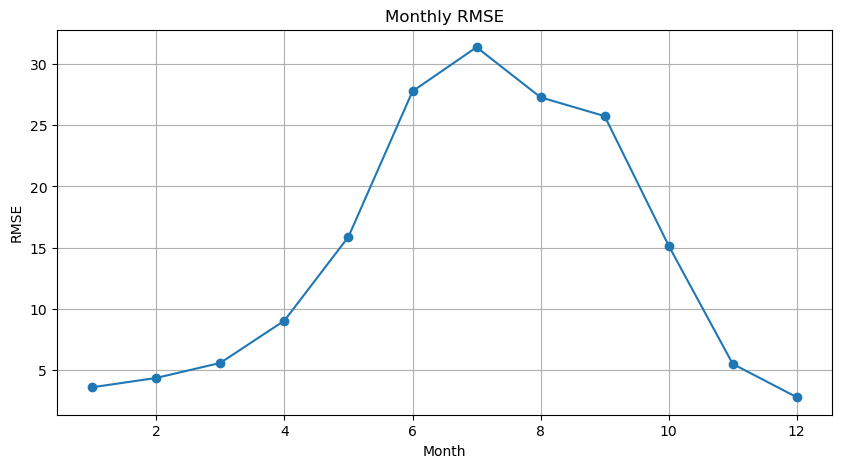

In [53]:

# 1. Monthly RMSE
monthly_rmse = plot_monthly_rmse(preds, targets, doy)

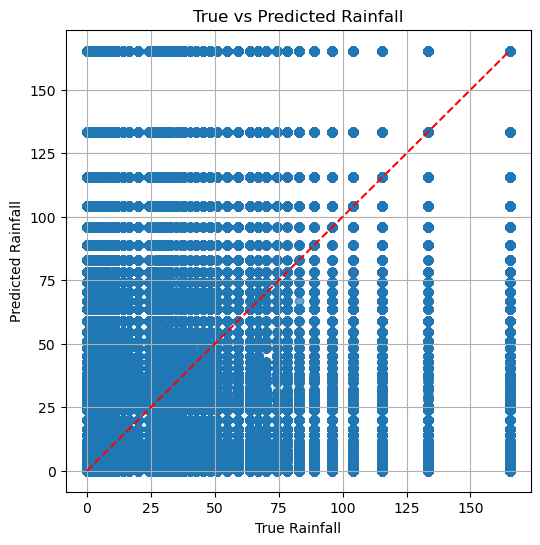

In [54]:

# 2. Scatter
plot_true_vs_pred(preds, targets)

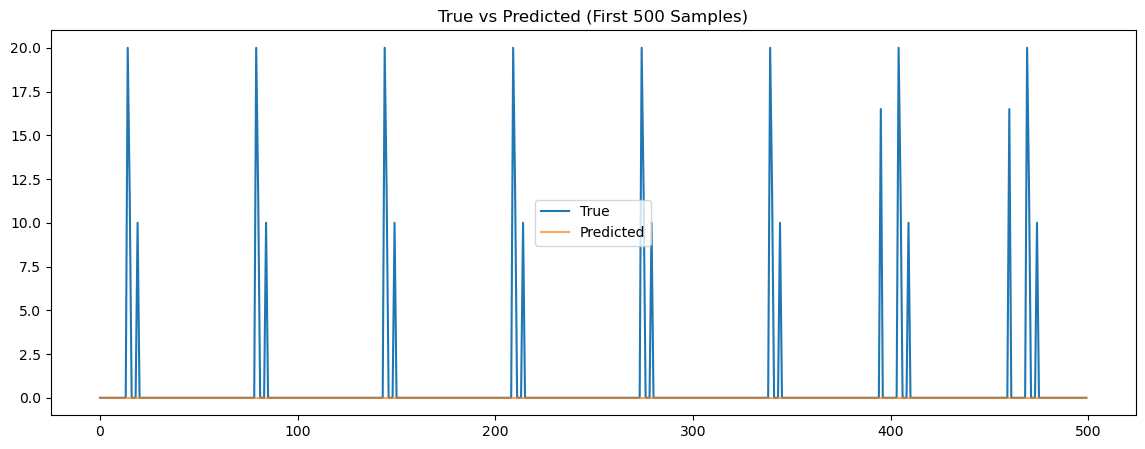

In [55]:

# 3. Overlay
plot_time_series_overlay(preds, targets)

In [56]:

# 4. Monsoon comparison
monsoon_results = monsoon_analysis(preds, targets, doy)
print(monsoon_results)

{'Non-Monsoon': {'RMSE': 9.229006890032618, 'MAE': 1.9294204711914062, 'Bias': -1.7860379}, 'Monsoon': {'RMSE': 28.154642582099694, 'MAE': 12.959114074707031, 'Bias': -10.150174}}


### Overall Evaluation Metrics

In [40]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

print("\nOverall Evaluation Metrics (FocalMSELoss):")
print(pd.DataFrame(overall_metrics, index=["Focal Loss Model"]).round(4))


Overall Evaluation Metrics (FocalMSELoss):
                     RMSE    MAE    Bias  NRMSE
Focal Loss Model  15.8465  6.958  0.2483   2.83


### Seasonal Evaluation

In [41]:
df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

print("\nSeasonal Performance:")
print(seasonal_metrics.round(4))


Seasonal Performance:
                RMSE      MAE    Bias
Monsoon      23.0612  13.3279  0.2348
Non-Monsoon   8.7386   2.9928  0.2567


### Per-Station Performance

In [42]:
df_station_metrics = stationwise_metrics(df_eval)

print("\nStation-wise metrics summary:")
print(df_station_metrics.describe().round(4))


Station-wise metrics summary:
           RMSE       MAE      Bias      Count
count  283.0000  283.0000  283.0000   283.0000
mean    13.8659    6.7035    0.3891  2067.5583
std      6.5987    2.9028    1.4290  1583.1979
min      0.4022    0.4022   -5.1198     1.0000
25%     10.2240    5.1802    0.0599   798.5000
50%     12.3854    5.9536    0.6902  1746.0000
75%     16.3289    8.1336    1.1372  2915.0000
max     40.9501   20.7433    6.7810  6532.0000


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


### Month-wise RMSE

C:\Users\rishe\AppData\Local\Temp\ipykernel_1144\1191928291.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


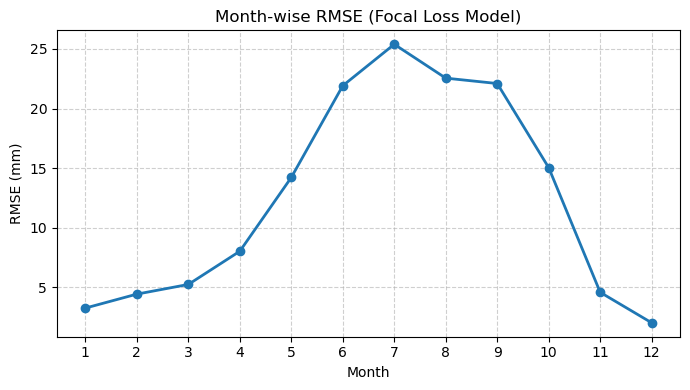

In [43]:
# Compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE (Focal Loss Model)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Error Distribution Analysis

In [44]:
# Error statistics
print("Error Statistics:")
print((df_eval['error']).describe(percentiles=[0.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, .95, .96, .97, .98, .99]).round(4))

Error Statistics:
count    585119.0000
mean         -0.2483
std          15.8445
min         -65.8873
10%          -9.8821
20%          -6.8366
25%          -5.4307
30%          -4.1507
40%          -2.1771
50%          -1.2294
60%          -0.8824
70%          -0.5884
75%          -0.4845
80%          -0.3889
90%           6.6954
95%          21.1432
96%          26.5267
97%          33.8525
98%          45.1860
99%          67.5920
max         597.4730
Name: error, dtype: float64


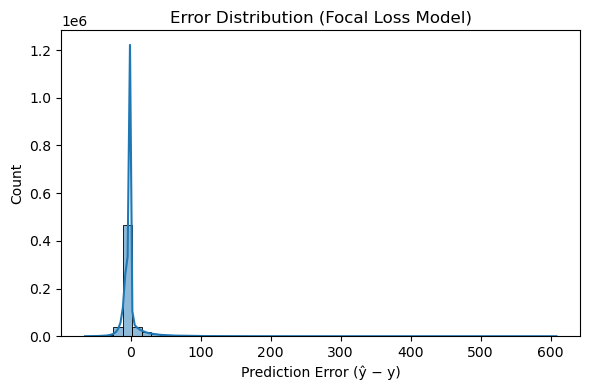

In [37]:
# Error histogram
plt.figure(figsize=(6, 4))
sns.histplot(df_eval['error'], bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution (Focal Loss Model)")
plt.tight_layout()
plt.show()

### Rainy vs Non-Rainy Analysis

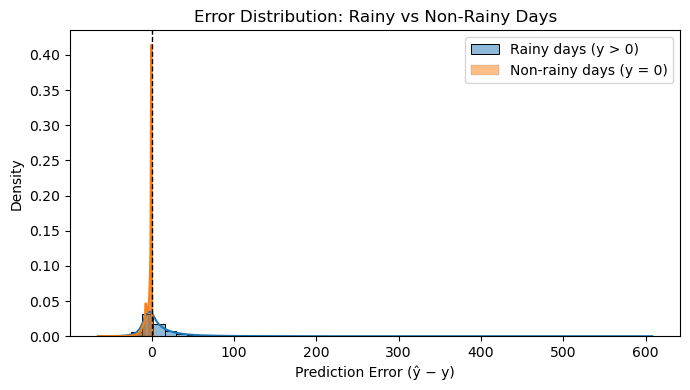

In [38]:
# Error histogram by rainfall regime
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()

### Monsoon vs Non-Monsoon Analysis

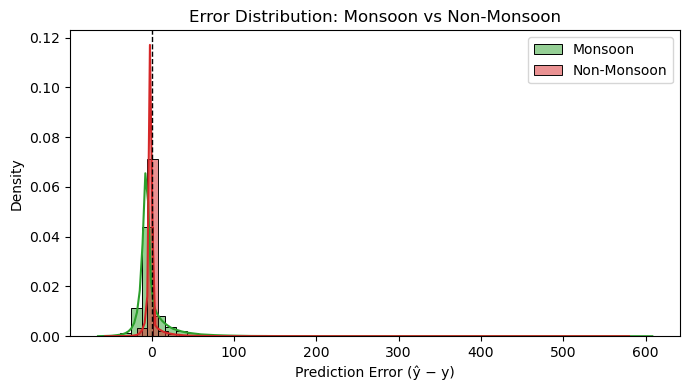

In [39]:
# Error histogram by season
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()

### Conditional RMSE Analysis

In [45]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

conditional_metrics = pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])

print("\nConditional RMSE by Rainfall Regime:")
print(conditional_metrics.round(4))


Conditional RMSE by Rainfall Regime:
          Regime     RMSE      MAE     Bias   Count
0      Non-rainy   5.7504   3.5164   3.5144  418736
1     Light rain   9.6914   7.0843   6.0705   83453
2  Moderate rain  16.9883  13.5517 -10.9516   66988
3     Heavy rain  81.5081  68.9891 -68.9565   15942


### Baseline Comparison

In [52]:
# Baseline models
yhat_zero = np.zeros_like(df_eval.y)
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Focal Loss Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

print("\nBaseline Comparison:")
print(baseline_table.round(4))


Baseline Comparison:
                     RMSE     MAE
Focal Loss Model  15.8327  6.8987
Zero Predictor    18.4014  5.5994
Mean Predictor    17.5288  8.6405


### Scatter Plot: True vs Predicted

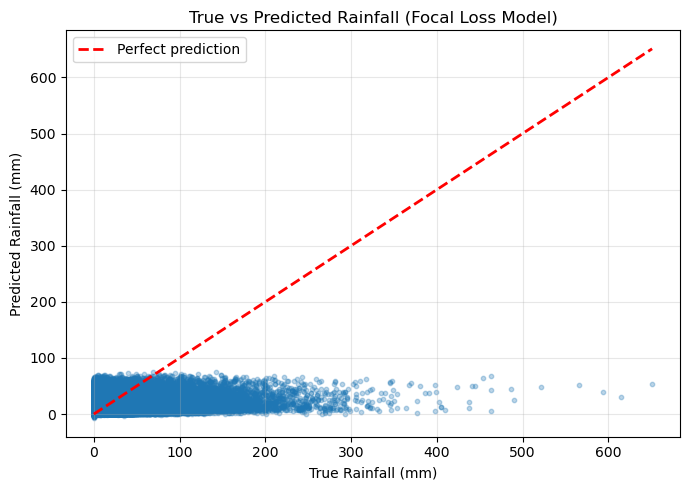

In [46]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_eval["y"],
    df_eval["yhat"],
    alpha=0.3,
    s=10
)

# Perfect prediction line
max_val = max(df_eval["y"].max(), df_eval["yhat"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted Rainfall (Focal Loss Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

In [43]:
summary_data = [
    {"Metric": "RMSE", "Value": overall_metrics["RMSE"]},
    {"Metric": "MAE", "Value": overall_metrics["MAE"]},
    {"Metric": "Bias", "Value": overall_metrics["Bias"]},
    {"Metric": "NRMSE", "Value": overall_metrics["NRMSE"]},
]

print(f"\n{'='*60}")
print(f"EXPERIMENT SUMMARY: FocalMSELoss (γ={FOCAL_GAMMA})")
print(f"{'='*60}")
print(f"Window Length: {L} days")
print(f"Horizon: {H} day")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Hidden Dimension: {HIDDEN_DIM}")
print(f"\nResults:")
print(pd.DataFrame(summary_data).to_string(index=False))
print(f"{'='*60}")


EXPERIMENT SUMMARY: FocalMSELoss (γ=2.0)
Window Length: 30 days
Horizon: 1 day
Batch Size: 64
Epochs: 10
Learning Rate: 0.001
Hidden Dimension: 128

Results:
Metric     Value
  RMSE 15.822738
   MAE  6.899314
  Bias  0.244747
 NRMSE  2.826602
